In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
## read the dataset

from google.colab import files
files.upload()

Saving californian_housing.csv to californian_housing.csv


{'californian_housing.csv': b',MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price\n0,8.3252,41.0,6.984126984126984,1.0238095238095237,322.0,2.5555555555555554,37.88,-122.23,Tr\xc3\xa8s Ch\xc3\xa8re\n1,8.3014,21.0,6.238137082601054,0.9718804920913884,2401.0,2.109841827768014,37.86,-122.22,Tr\xc3\xa8s Ch\xc3\xa8re\n2,7.2574,52.0,8.288135593220339,1.073446327683616,496.0,2.8022598870056497,37.85,-122.24,Tr\xc3\xa8s Ch\xc3\xa8re\n3,5.6431,52.0,5.8173515981735155,1.0730593607305936,558.0,2.547945205479452,37.85,-122.25,Tr\xc3\xa8s Ch\xc3\xa8re\n4,3.8462,52.0,6.281853281853282,1.0810810810810811,565.0,2.1814671814671813,37.85,-122.25,Tr\xc3\xa8s Ch\xc3\xa8re\n5,4.0368,52.0,4.761658031088083,1.1036269430051813,413.0,2.139896373056995,37.85,-122.25,Ch\xc3\xa8re\n6,3.6591,52.0,4.9319066147859925,0.9513618677042801,1094.0,2.1284046692607004,37.84,-122.25,Ch\xc3\xa8re\n7,3.12,52.0,4.797527047913447,1.061823802163833,1157.0,1.7882534775888717,37.84,-122.25,Ch\xc3\xa8re

In [4]:
dataset = pd.read_csv("californian_housing.csv", index_col =0)
dataset

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,Très Chère
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,Très Chère
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,Très Chère
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,Très Chère
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,Très Chère
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,Peu chère
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,Peu chère
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,Peu chère
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,Peu chère


In [5]:
dataset.Price.value_counts()

,count
Price,
Moyennement chère,8289
Chère,4889
Très Chère,3866
Peu chère,3596


In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  object 
dtypes: float64(8), object(1)
memory usage: 1.6+ MB


In [7]:
## preparing the data for the model
X = dataset.drop(columns="Price")
y= dataset.Price

In [8]:
## encode the target variable
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [9]:
le.classes_

array(['Chère', 'Moyennement chère', 'Peu chère', 'Très Chère'],
      dtype=object)

In [12]:
pd.Series(y).value_counts()

,count
1,8289
0,4889
3,3866
2,3596


In [13]:
# train test split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
## model the data with e decision tree

from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(min_samples_leaf=50)
dt.fit(X_train, y_train)

DecisionTreeClassifier(min_samples_leaf=50)

[Text(0.6143323863636364, 0.96875, 'x[0] <= 5.032\ngini = 0.718\nsamples = 16512\nvalue = [3933, 6605, 2866, 3108]'),
 Text(0.3227556818181818, 0.90625, 'x[0] <= 2.593\ngini = 0.669\nsamples = 12943\nvalue = [2704, 6211, 2856, 1172]'),
 Text(0.4685440340909091, 0.9375, 'True  '),
 Text(0.13670454545454547, 0.84375, 'x[6] <= 34.445\ngini = 0.597\nsamples = 4260\nvalue = [345, 1822, 1962, 131]'),
 Text(0.07318181818181818, 0.78125, 'x[7] <= -117.375\ngini = 0.582\nsamples = 2036\nvalue = [223, 1169, 557, 87]'),
 Text(0.04454545454545455, 0.71875, 'x[7] <= -118.225\ngini = 0.532\nsamples = 1374\nvalue = [192.0, 893.0, 209.0, 80.0]'),
 Text(0.02727272727272727, 0.65625, 'x[6] <= 34.045\ngini = 0.644\nsamples = 798\nvalue = [159, 415, 156, 68]'),
 Text(0.014545454545454545, 0.59375, 'x[7] <= -118.285\ngini = 0.547\nsamples = 483\nvalue = [25, 288, 147, 23]'),
 Text(0.007272727272727273, 0.53125, 'x[7] <= -118.345\ngini = 0.423\nsamples = 212\nvalue = [19, 158, 18, 17]'),
 Text(0.00363636363

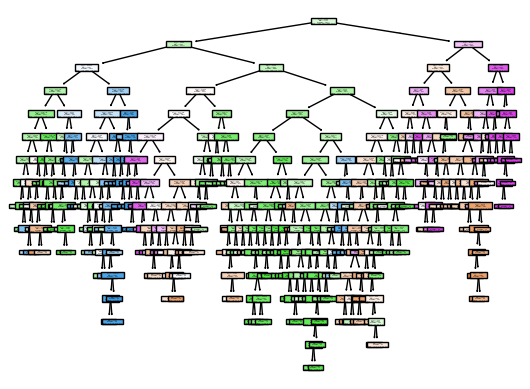

In [17]:
## diagram of the tree
from sklearn import tree
tree.plot_tree(dt, filled=True)

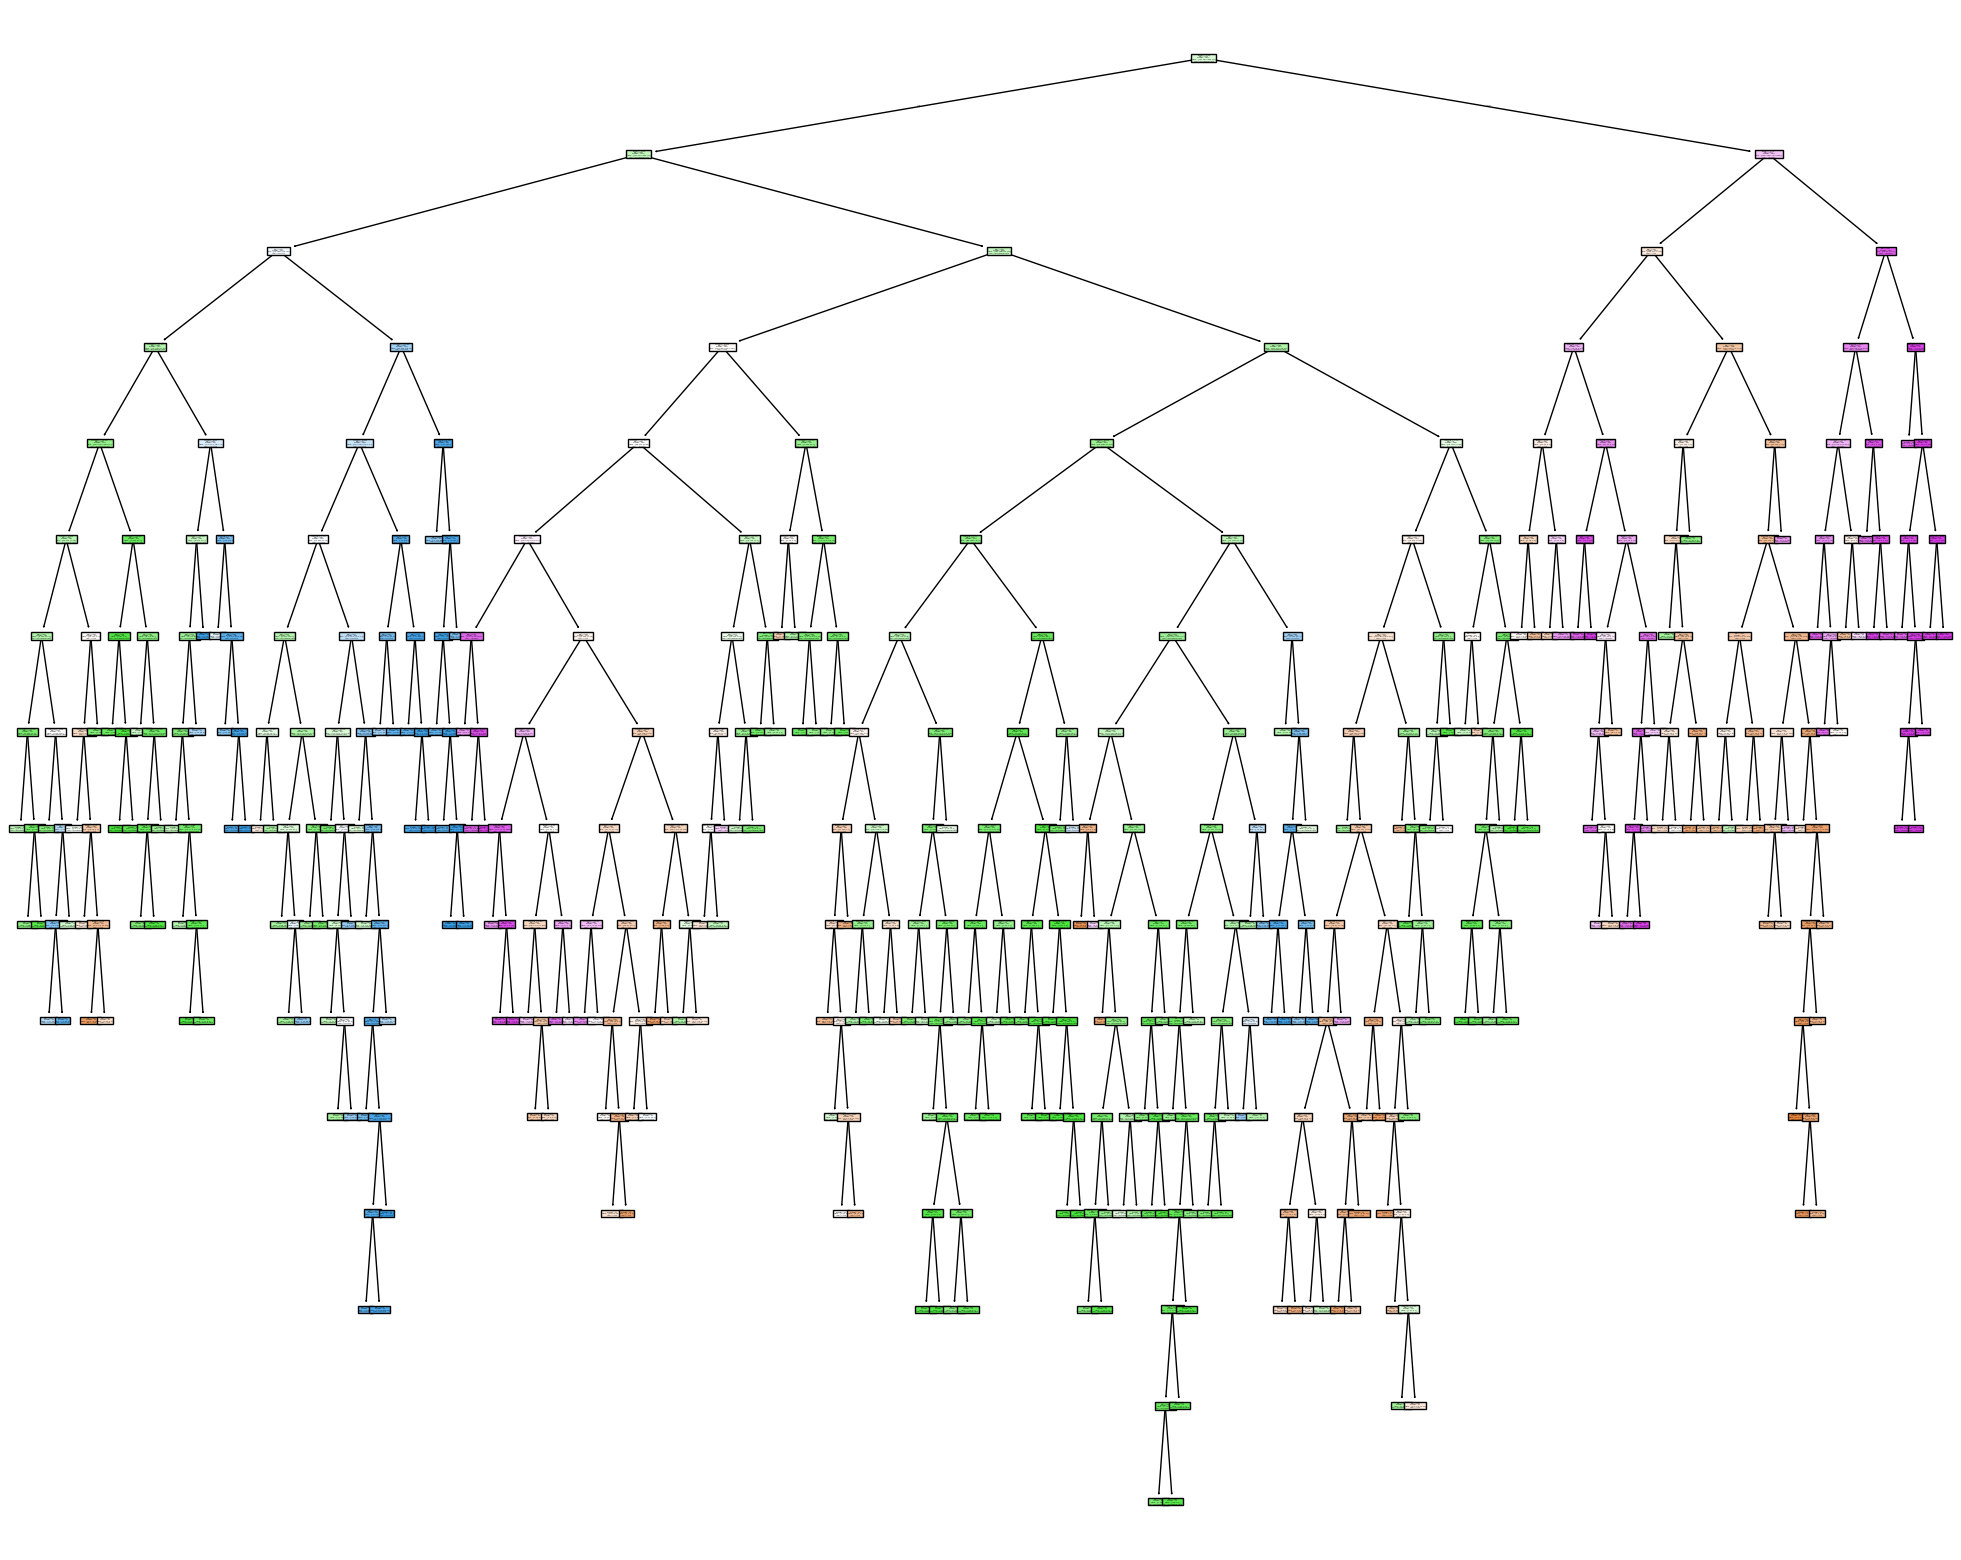

In [18]:
fig = plt.figure(figsize =(25,20))

_ = tree.plot_tree(dt,
                   feature_names=X.columns,
                   class_names=le.classes_,
                   filled=True)

In [19]:
text_representation = tree.export_text(dt)
print(text_representation)

|--- feature_0 <= 5.03
|   |--- feature_0 <= 2.59
|   |   |--- feature_6 <= 34.44
|   |   |   |--- feature_7 <= -117.38
|   |   |   |   |--- feature_7 <= -118.23
|   |   |   |   |   |--- feature_6 <= 34.05
|   |   |   |   |   |   |--- feature_7 <= -118.28
|   |   |   |   |   |   |   |--- feature_7 <= -118.34
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- feature_7 >  -118.34
|   |   |   |   |   |   |   |   |--- feature_6 <= 34.00
|   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |   |--- feature_6 >  34.00
|   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- feature_7 >  -118.28
|   |   |   |   |   |   |   |--- feature_2 <= 3.56
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- feature_2 >  3.56
|   |   |   |   |   |   |   |   |--- feature_6 <= 33.97
|   |   |   |   |   |   |   |   |   |--- feature_6 <= 33.93
|   |   |   |   |   |   |   |   |   |   |--- class: 2
|   |   | 

In [20]:
## evaluating the model

print("evaluation of the model on the train set", dt.score(X_train, y_train))
print("evaluation of the model on the test set", dt.score(X_test, y_test))

evaluation of the model on the train set 0.727531492248062
evaluation of the model on the test set 0.6935562015503876


In [28]:
dt.predict(X_train)

array([1, 3, 1, ..., 1, 0, 0])

In [32]:
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
# predictions
y_pred_train = dt.predict(X_train)
y_pred_test = dt.predict(X_test)
label_names = le.classes_
#classification report
classification_report(y_train, y_pred_train)
print(classification_report(y_train, y_pred_train, target_names=label_names))

                   precision    recall  f1-score   support

            Chère       0.63      0.62      0.63      3933
Moyennement chère       0.73      0.80      0.76      6605
        Peu chère       0.80      0.72      0.75      2866
       Très Chère       0.79      0.72      0.75      3108

         accuracy                           0.73     16512
        macro avg       0.74      0.71      0.72     16512
     weighted avg       0.73      0.73      0.73     16512



In [33]:
print(classification_report(y_test, y_pred_test, target_names=label_names))

                   precision    recall  f1-score   support

            Chère       0.58      0.57      0.57       956
Moyennement chère       0.71      0.76      0.73      1684
        Peu chère       0.76      0.70      0.73       730
       Très Chère       0.76      0.70      0.73       758

         accuracy                           0.69      4128
        macro avg       0.70      0.68      0.69      4128
     weighted avg       0.69      0.69      0.69      4128



Text(50.722222222222214, 0.5, 'Truth')

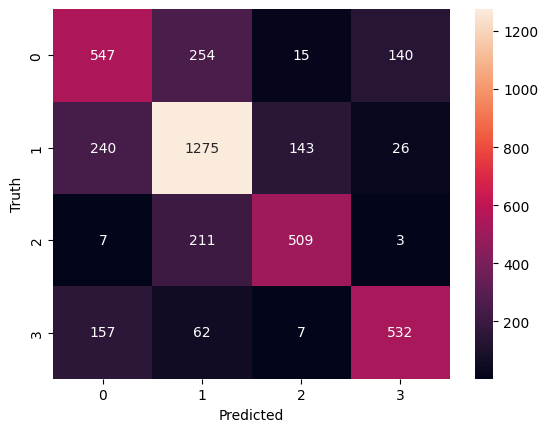

In [34]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_test)

sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [38]:
## feature importance

feature_importance = pd.DataFrame({"Features": dataset.columns[:-1],
                                  "contribution_feature": dt.feature_importances_})

feature_importance.sort_values("contribution_feature", ascending=False)

,Features,contribution_feature
0,MedInc,0.395740
7,Longitude,0.207303
6,Latitude,0.189289
5,AveOccup,0.134715
1,HouseAge,0.036649
2,AveRooms,0.020399
4,Population,0.009002
3,AveBedrms,0.006903


In [39]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, min_samples_leaf=50)
rf.fit(X_train, y_train)

RandomForestClassifier(min_samples_leaf=50)

In [40]:
## random forest model
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
# predictions
y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)
label_names = le.classes_
#classification report
classification_report(y_train, y_pred_train)
print(classification_report(y_train, y_pred_train, target_names=label_names))

                   precision    recall  f1-score   support

            Chère       0.69      0.58      0.63      3933
Moyennement chère       0.70      0.87      0.78      6605
        Peu chère       0.84      0.66      0.74      2866
       Très Chère       0.83      0.74      0.78      3108

         accuracy                           0.74     16512
        macro avg       0.77      0.71      0.73     16512
     weighted avg       0.75      0.74      0.74     16512



In [41]:
## decision tree model
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
# predictions
y_pred_train = dt.predict(X_train)
y_pred_test = dt.predict(X_test)
label_names = le.classes_
#classification report
classification_report(y_train, y_pred_train)
print(classification_report(y_train, y_pred_train, target_names=label_names))

                   precision    recall  f1-score   support

            Chère       0.63      0.62      0.63      3933
Moyennement chère       0.73      0.80      0.76      6605
        Peu chère       0.80      0.72      0.75      2866
       Très Chère       0.79      0.72      0.75      3108

         accuracy                           0.73     16512
        macro avg       0.74      0.71      0.72     16512
     weighted avg       0.73      0.73      0.73     16512



In [43]:
## decision tree model
print(classification_report(y_test, y_pred_test, target_names=label_names))

                   precision    recall  f1-score   support

            Chère       0.58      0.57      0.57       956
Moyennement chère       0.71      0.76      0.73      1684
        Peu chère       0.76      0.70      0.73       730
       Très Chère       0.76      0.70      0.73       758

         accuracy                           0.69      4128
        macro avg       0.70      0.68      0.69      4128
     weighted avg       0.69      0.69      0.69      4128



In [44]:
## random forest model
print(classification_report(y_test, rf.predict(X_test), target_names=label_names))

                   precision    recall  f1-score   support

            Chère       0.64      0.55      0.59       956
Moyennement chère       0.69      0.84      0.76      1684
        Peu chère       0.82      0.65      0.72       730
       Très Chère       0.82      0.72      0.77       758

         accuracy                           0.72      4128
        macro avg       0.74      0.69      0.71      4128
     weighted avg       0.72      0.72      0.71      4128

